## 8. Khám Phá Dữ Liệu Chuyên Sâu (Deep EDA)

Phân tích trên tập dữ liệu đã lọc (liên tục, không còn đứt gãy lớn) nhằm:
- Quan sát xu hướng và chu kỳ theo thời gian (giờ / tháng)
- Đánh giá tương quan giữa PM2.5 và các biến khí tượng
- Cung cấp cơ sở khoa học cho việc chọn features (ACF/PACF justify lag selection)


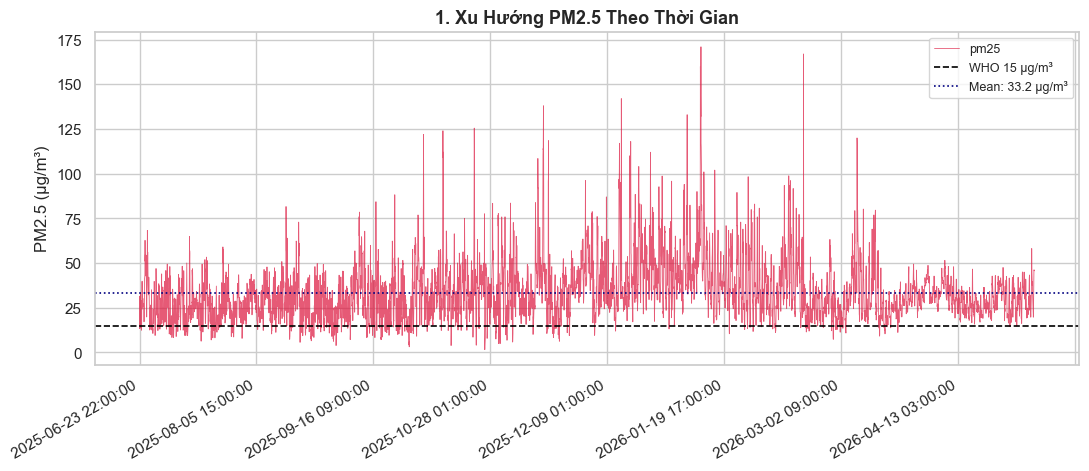

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ══════════════════════════════════════════════════════════════════
# 6.1 TỔNG QUAN DỮ LIỆU
# ══════════════════════════════════════════════════════════════════
eda_df = pd.read_csv('../data/merged_final.csv')
eda_df['time'] = pd.to_datetime(eda_df['time'])
eda_df = eda_df.set_index('time').sort_index()

print("═" * 60)
print("TỔNG QUAN DỮ LIỆU EDA")
print("═" * 60)
print(f"Thời gian: {eda_df.index.min()} → {eda_df.index.max()}")
print(f"Tổng số giờ: {len(eda_df):,}")
print(f"Tỷ lệ PM2.5 hợp lệ: {eda_df['pm25'].notna().mean()*100:.2f}%")
print(f"Trung bình PM2.5: {eda_df['pm25'].mean():.2f} µg/m³")
print(f"Max PM2.5: {eda_df['pm25'].max():.1f} | Min: {eda_df['pm25'].min():.1f}")

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 6.2 MISSING VALUES ANALYSIS
# ══════════════════════════════════════════════════════════════════
import missingno as msno

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

msno.matrix(eda_df, ax=axes[0], sparkline=False)
axes[0].set_title('Missing Values Pattern', fontsize=14, fontweight='bold')

msno.bar(eda_df, ax=axes[1])
axes[1].set_title('Số lượng Missing theo cột', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 6.3 TIME SERIES PM2.5
# ══════════════════════════════════════════════════════════════════
plt.figure(figsize=(16, 7))

plt.plot(eda_df.index, eda_df['pm25'], color='crimson', linewidth=0.8, alpha=0.85, label='PM2.5')

plt.axhline(15, color='black', linestyle='--', linewidth=1.5, label='WHO Guideline (15 µg/m³)')
plt.axhline(eda_df['pm25'].mean(), color='navy', linestyle=':', linewidth=1.5,
            label=f'Trung bình = {eda_df["pm25"].mean():.1f} µg/m³')

plt.title('Nồng Độ PM2.5 Theo Thời Gian Tại TP. Hồ Chí Minh', fontsize=16, fontweight='bold')
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.xlabel('Thời gian', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Text(0, 0.5, 'PM2.5 (µg/m³)')

<Figure size 640x480 with 0 Axes>


THỐNG KÊ MÔ TẢ PM2.5:
count    7656.00
mean       33.24
std        16.18
min         1.55
25%        22.50
50%        30.60
75%        40.30
max       171.00
Name: pm25, dtype: float64

Tỷ lệ vượt WHO 15 µg/m³ : 92.6%
Tỷ lệ vượt WHO 25 µg/m³ : 67.2%


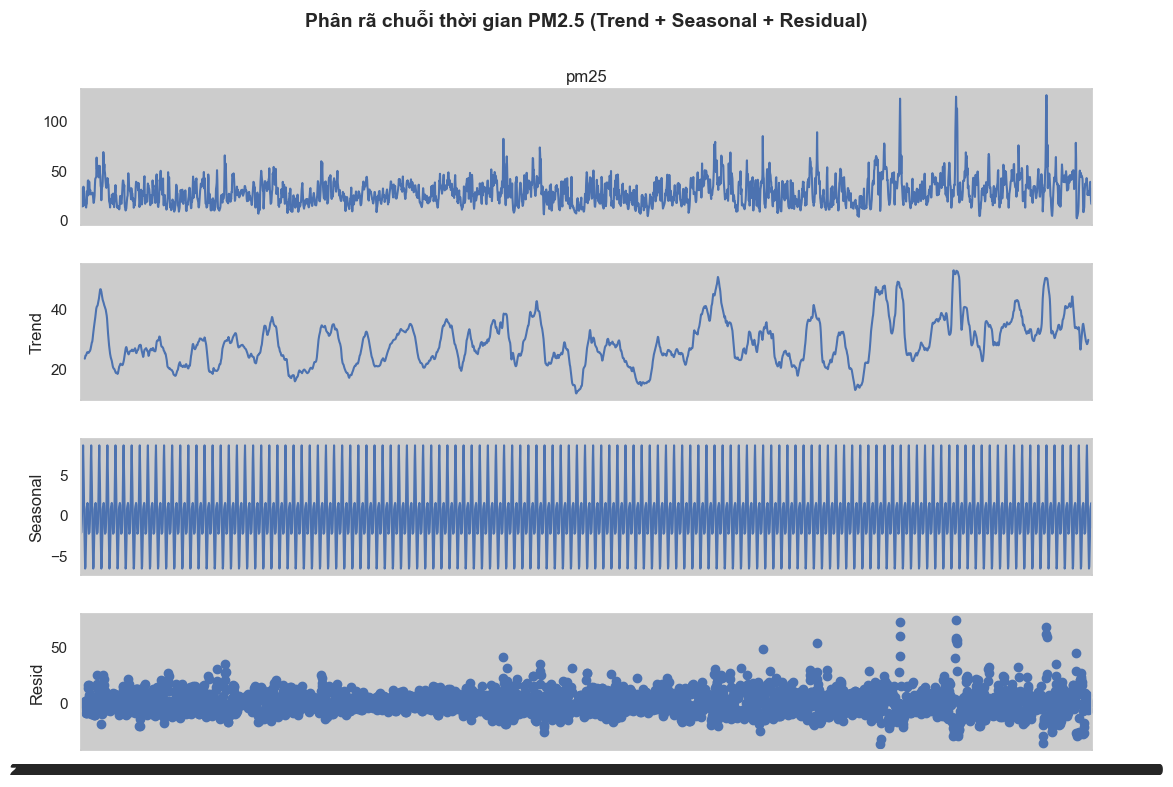

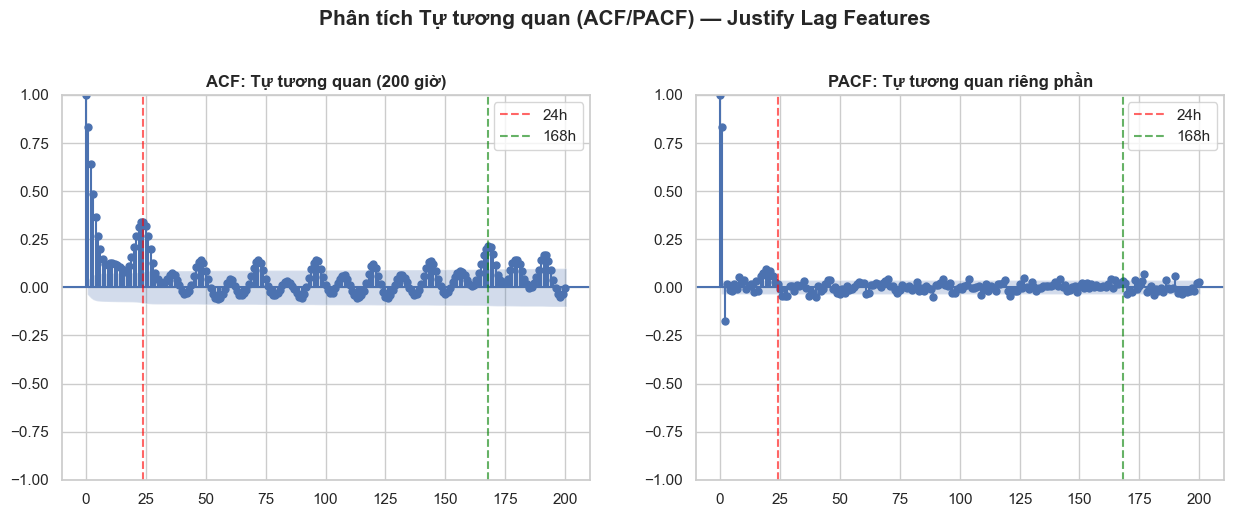

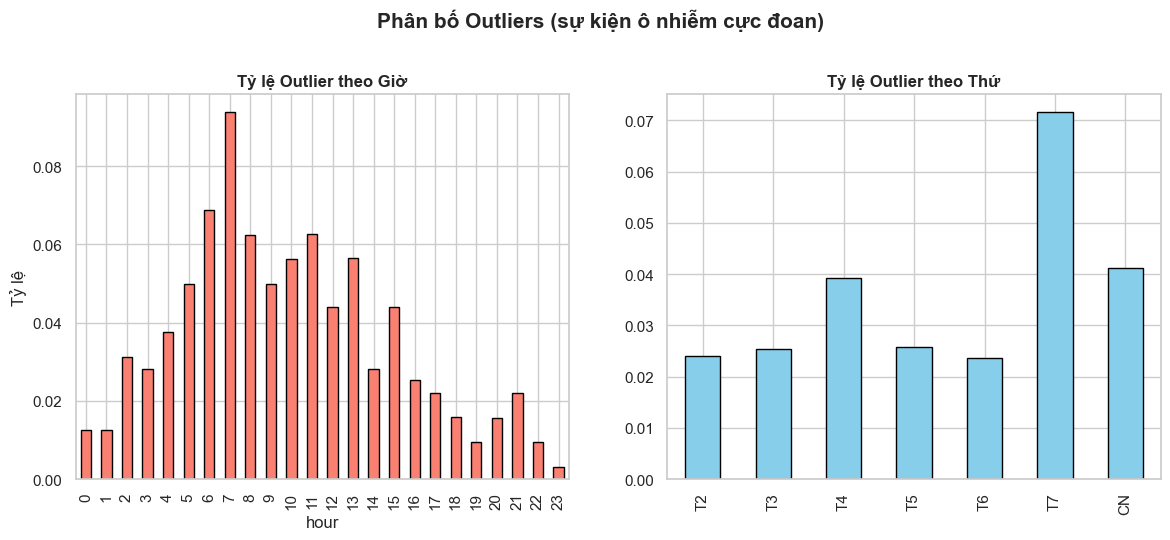

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 6.4 SEASONAL PATTERNS
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='hour', y='pm25', data=eda_df.reset_index(), ax=axes[0])
axes[0].set_title('PM2.5 theo Giờ trong ngày')

sns.boxplot(x='month', y='pm25', data=eda_df.reset_index(), ax=axes[1])
axes[1].set_title('PM2.5 theo Tháng')

sns.boxplot(x='dayofweek', y='pm25', data=eda_df.reset_index(), ax=axes[2])
axes[2].set_title('PM2.5 theo Thứ trong tuần')

plt.suptitle('Mô hình Mùa vụ của PM2.5', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 6.5 DISTRIBUTION & OUTLIERS
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(eda_df['pm25'].dropna(), kde=True, bins=50, ax=axes[0], color='crimson')
axes[0].set_title('Histogram phân phối PM2.5')
axes[0].axvline(eda_df['pm25'].mean(), color='blue', linestyle='--', label='Mean')

sns.boxplot(y=eda_df['pm25'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot PM2.5')

plt.suptitle('Phân phối và Outlier của PM2.5', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 6.6 CORRELATION ANALYSIS
# ══════════════════════════════════════════════════════════════════
plt.figure(figsize=(12, 9))
corr = eda_df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Ma trận Tương quan giữa các biến', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 6.7 SEASONAL DECOMPOSITION (chu kỳ 24h)
# ══════════════════════════════════════════════════════════════════
decomp = seasonal_decompose(eda_df['pm25'].dropna(), model='additive', period=24)

fig = decomp.plot()
fig.set_size_inches(15, 10)
fig.suptitle('Seasonal Decomposition của PM2.5 (period=24)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()